<a href="https://colab.research.google.com/github/wajd-mq/wajd-mq/blob/main/YOLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26.8


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ERO7fsLHwR1zp88fCiom")
project = rf.workspace("htl-k72br").project("trash-detection-qqvnb")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Trash-Detection-1 in yolov8:: 100%|██████████| 11746/11746 [00:01<00:00, 7336.34it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import os

print(dataset.location)

/content/Trash-Detection-1


In [ ]:
import os

for root, dirs, files in os.walk(dataset.location):
    print(root)


/content/Trash-Detection-1
/content/Trash-Detection-1/train
/content/Trash-Detection-1/train/images
/content/Trash-Detection-1/train/labels
/content/Trash-Detection-1/valid
/content/Trash-Detection-1/valid/images
/content/Trash-Detection-1/valid/labels
/content/Trash-Detection-1/test
/content/Trash-Detection-1/test/images
/content/Trash-Detection-1/test/labels


In [ ]:
import yaml

with open(f"{dataset.location}/data.yaml", "r") as f:
    data = yaml.safe_load(f)
print(data)

{'names': ['BIODEGRADABLE', 'CARDBOARD', 'GLASS', 'METAL', 'PAPER', 'PLASTIC'], 'nc': 6, 'roboflow': {'license': 'CC BY 4.0', 'project': 'trash-detection-qqvnb', 'url': 'https://universe.roboflow.com/htl-k72br/trash-detection-qqvnb/dataset/1', 'version': 1, 'workspace': 'htl-k72br'}, 'test': '../test/images', 'train': '../train/images', 'val': '../valid/images'}


In [ ]:
from ultralytics import YOLO

# تحميل النموذج الأساسي
model = YOLO("yolov8n.pt")

# بدء التدريب
results = model.train(
    data="/content/Trash-Detection-1/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    workers=2,
    name="trash_detection"
)

Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Trash-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=trash_detection, nbs=64, nms=False, opset=None, optimize=False, optimizer=aut

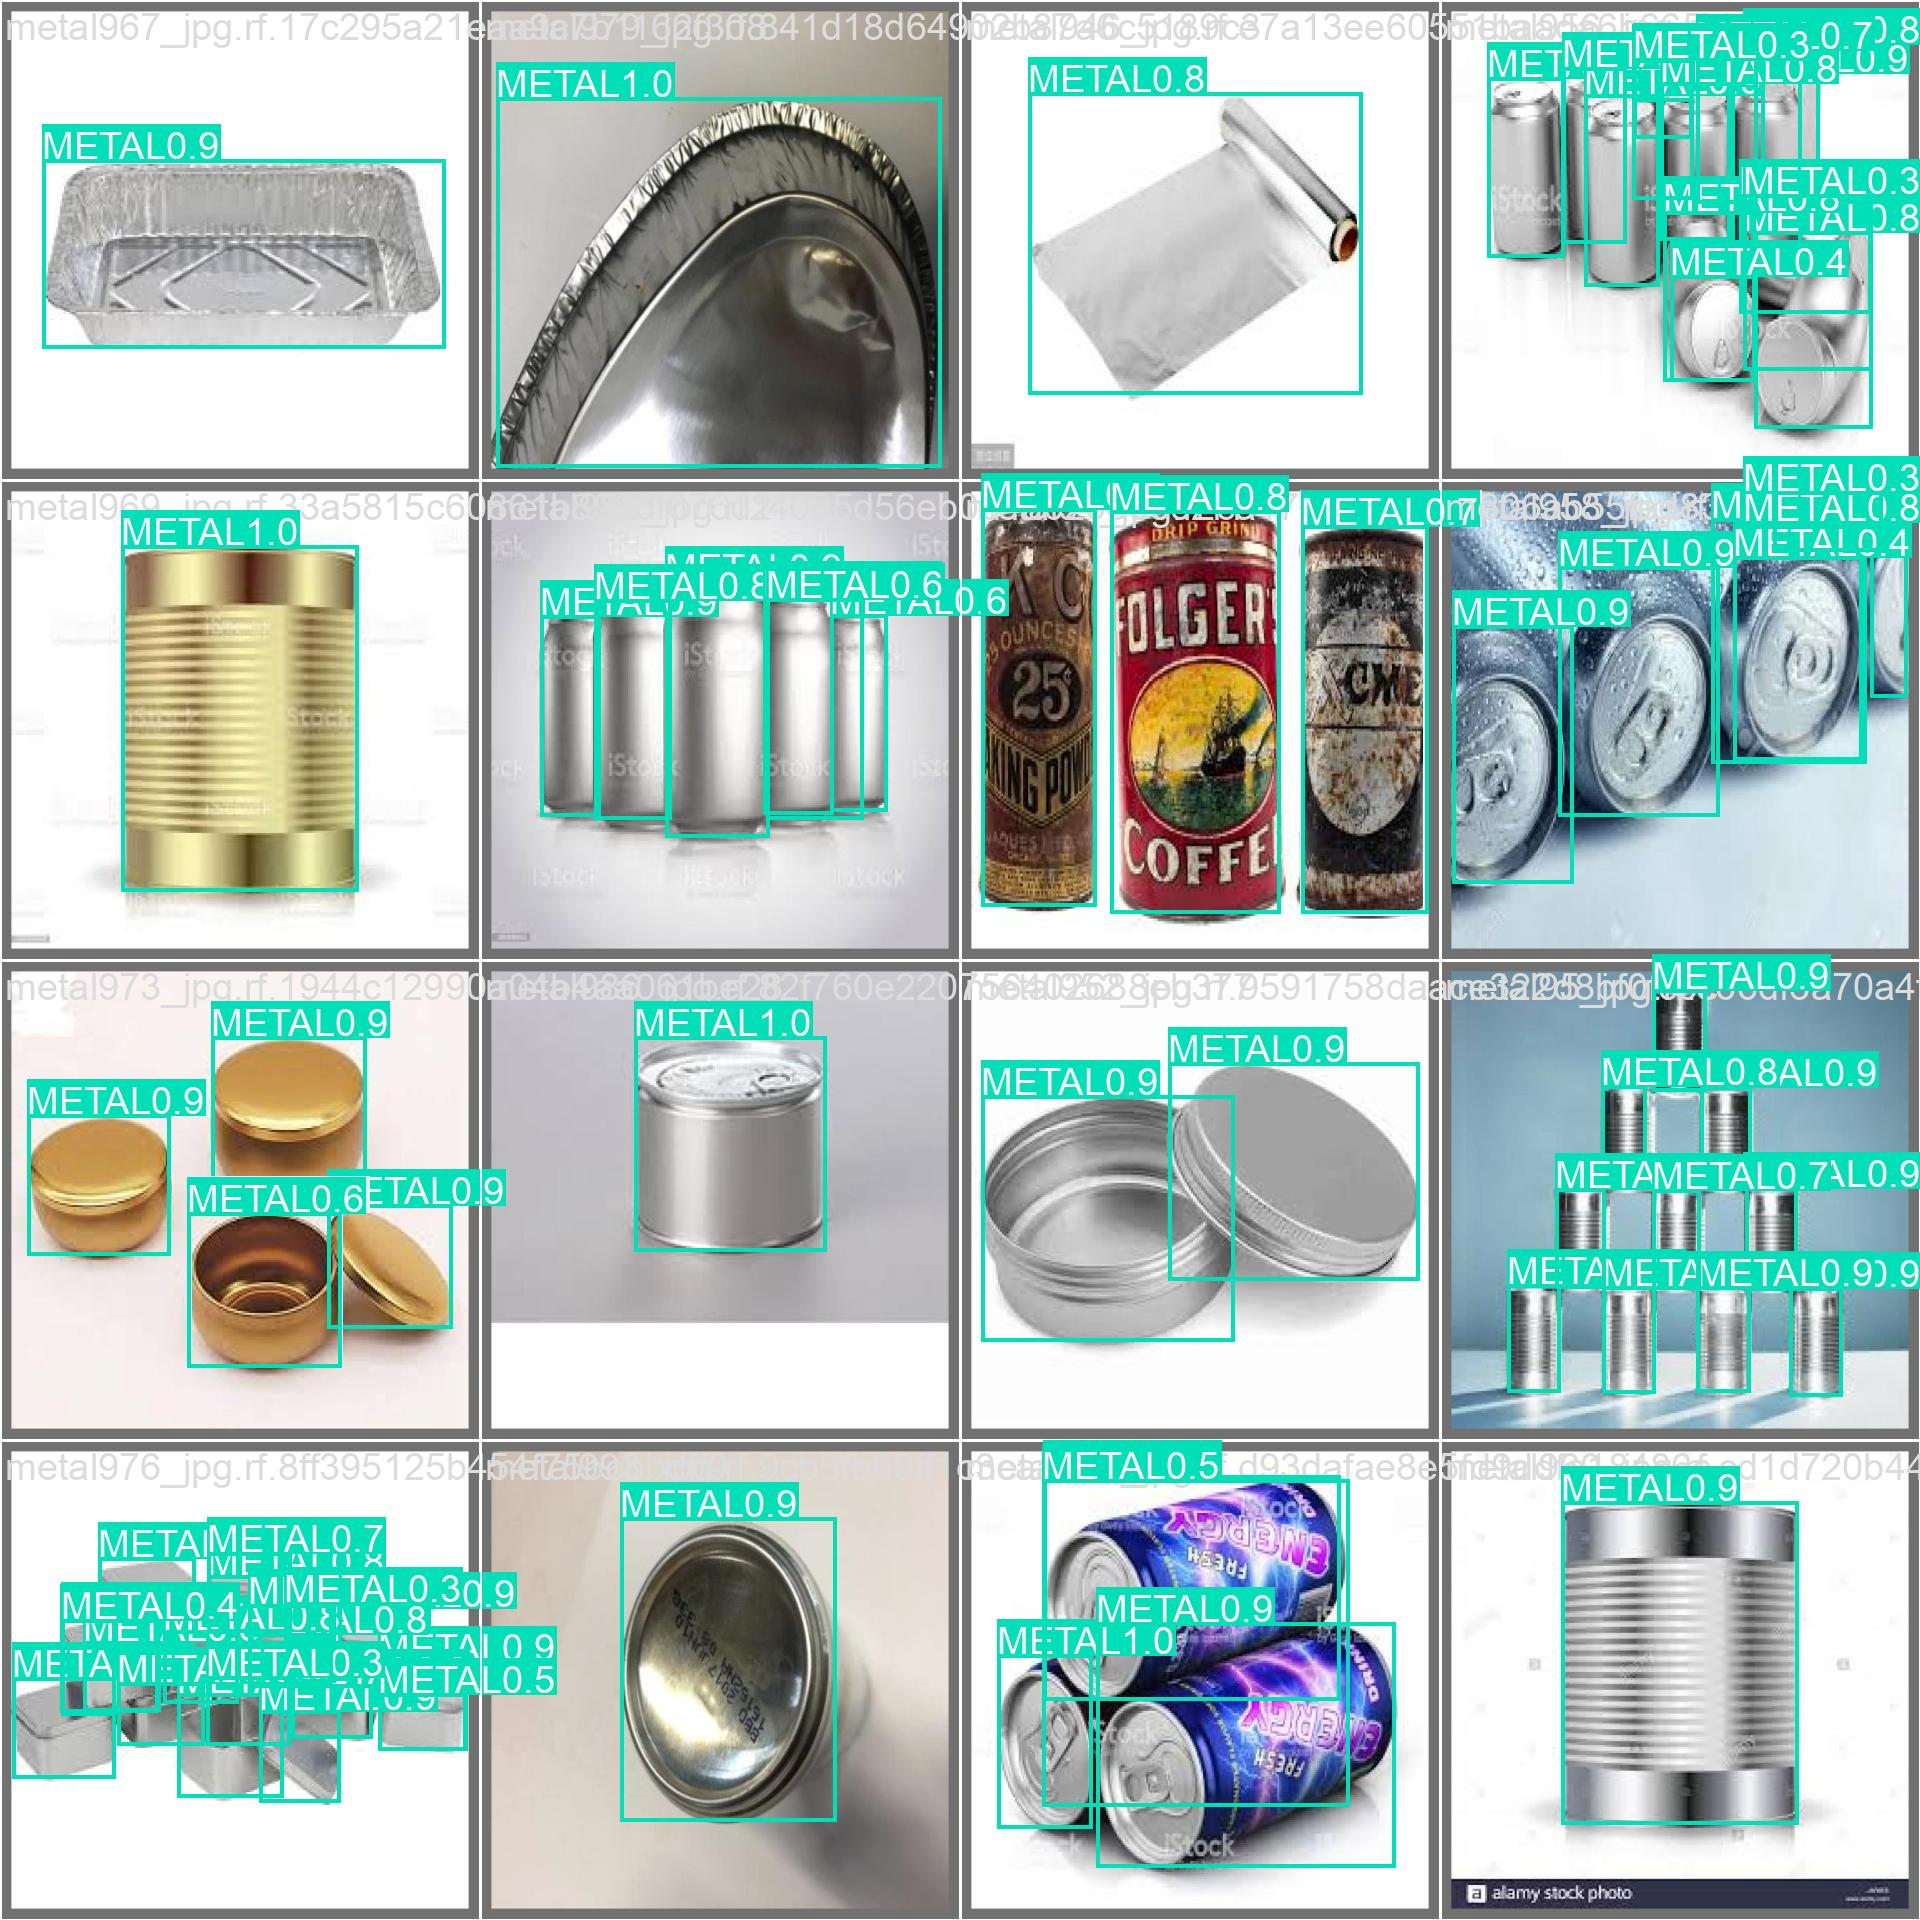

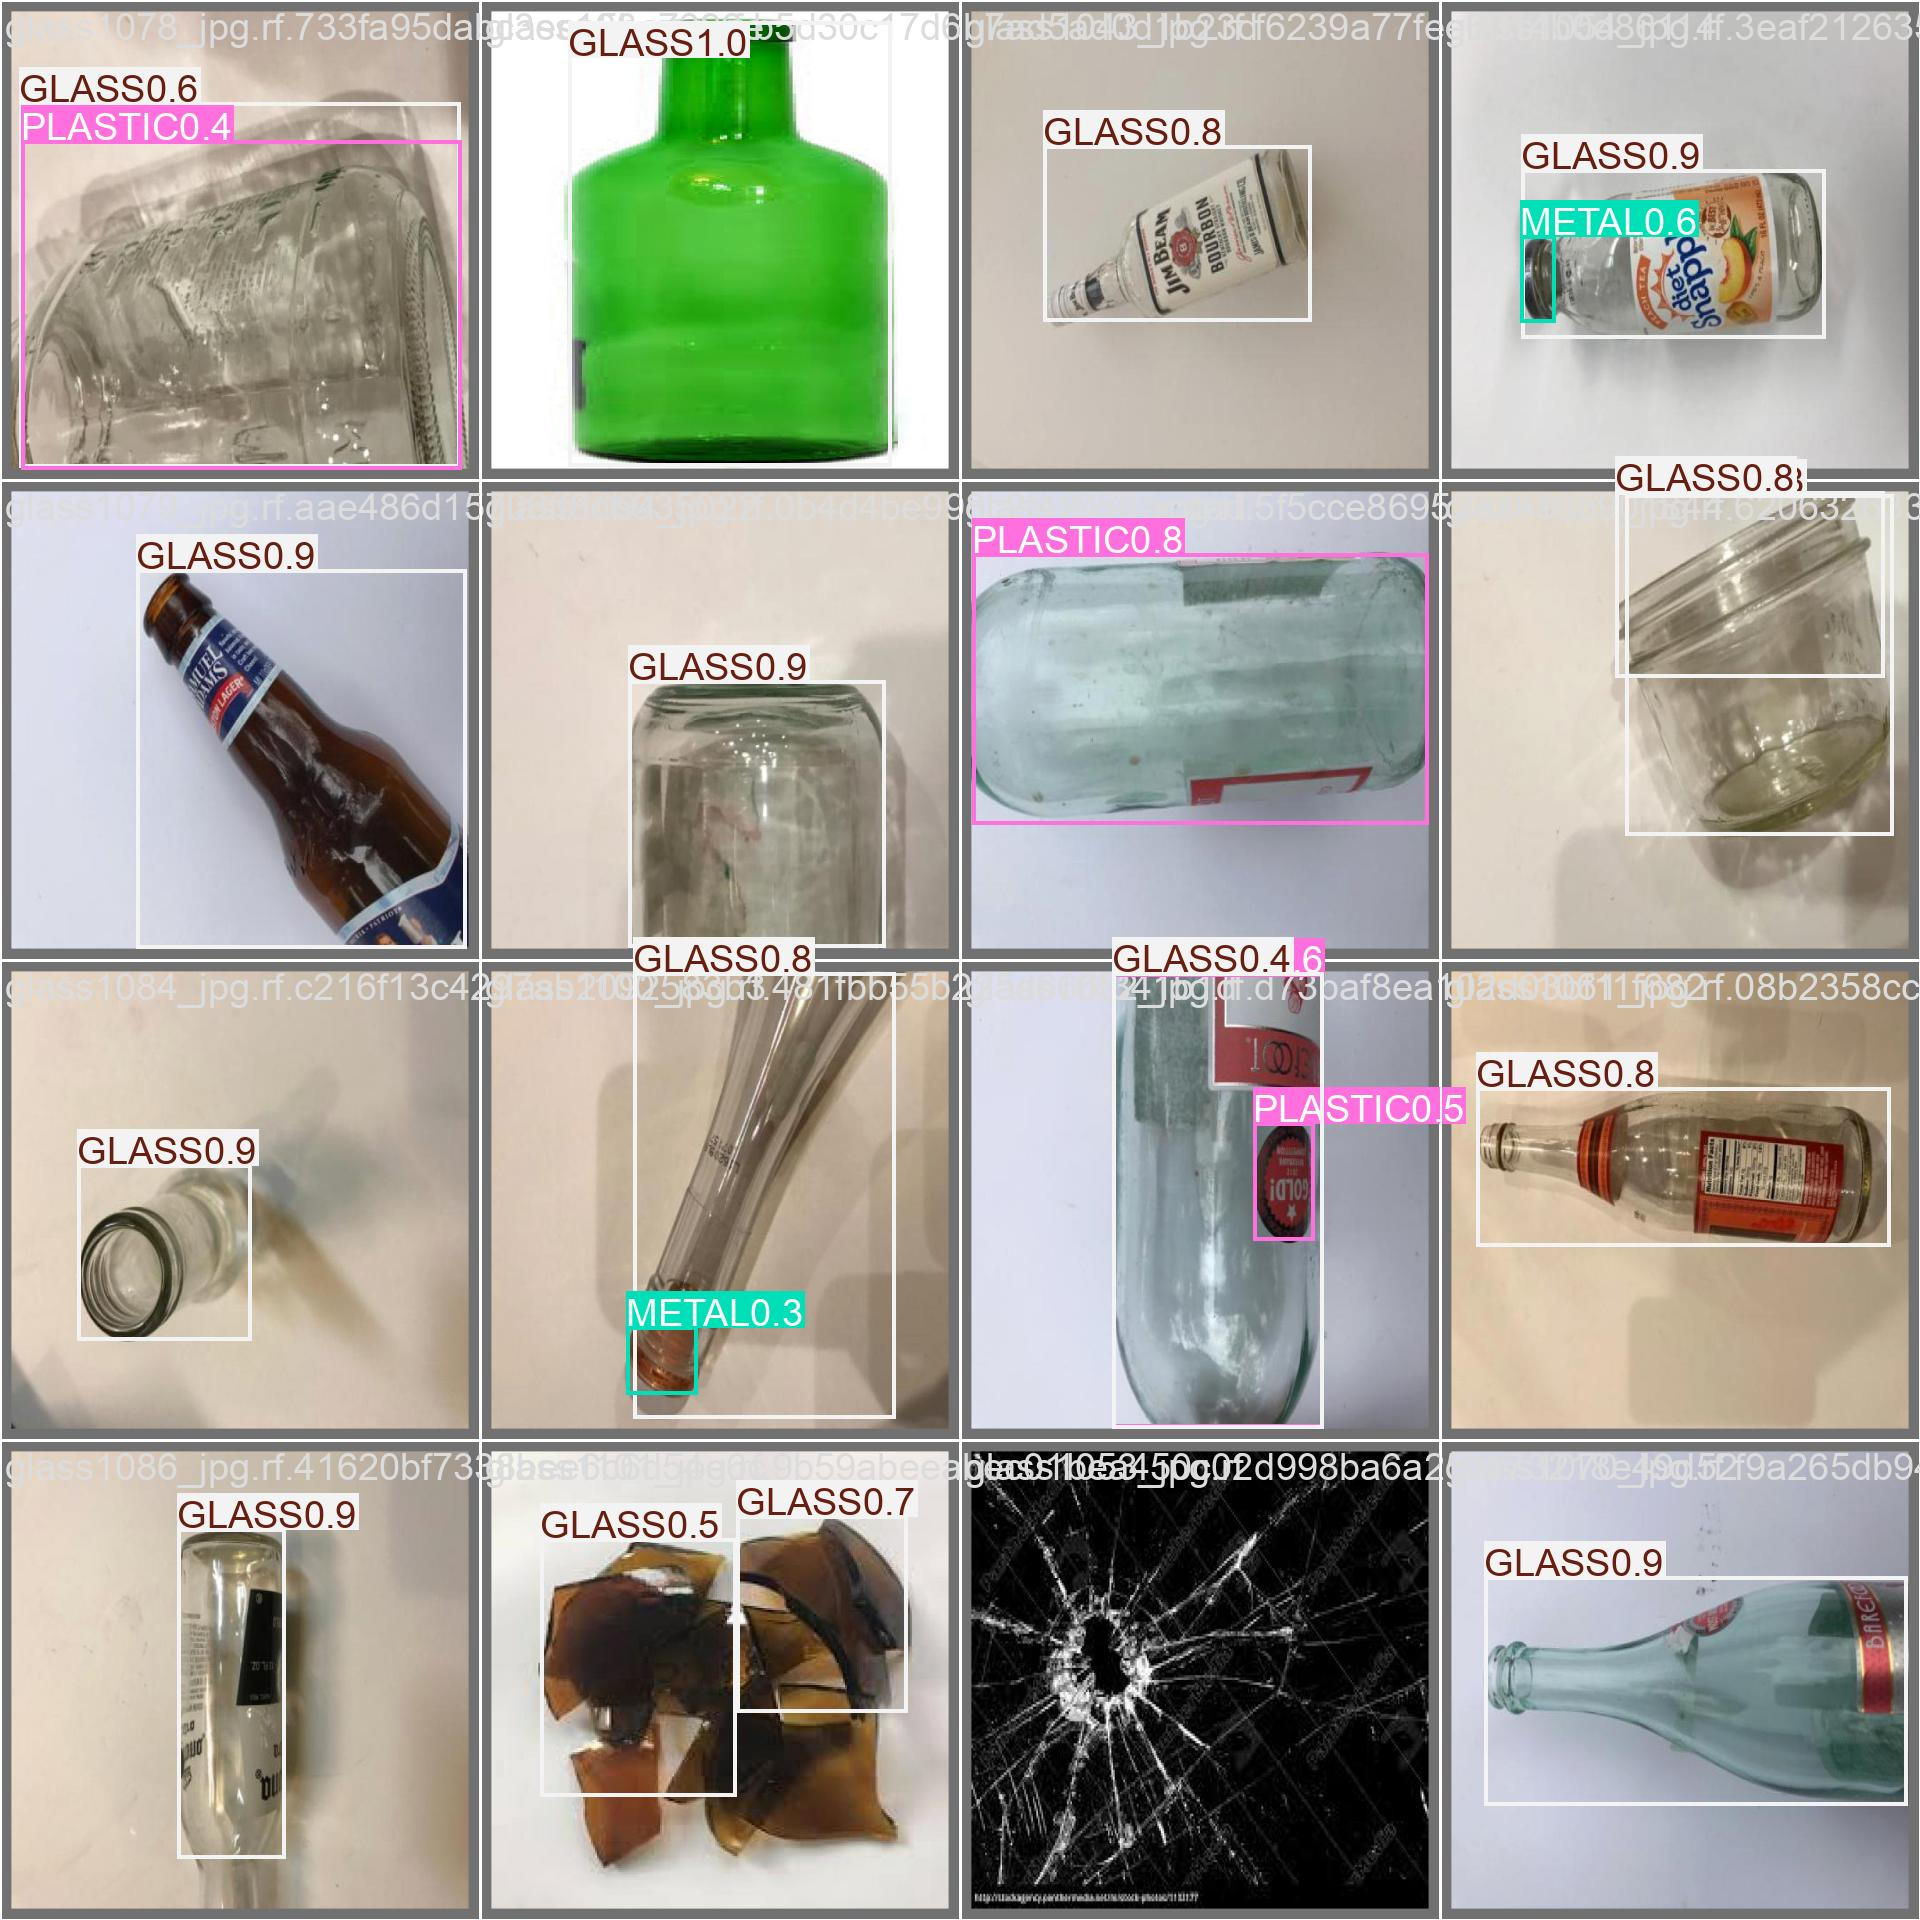

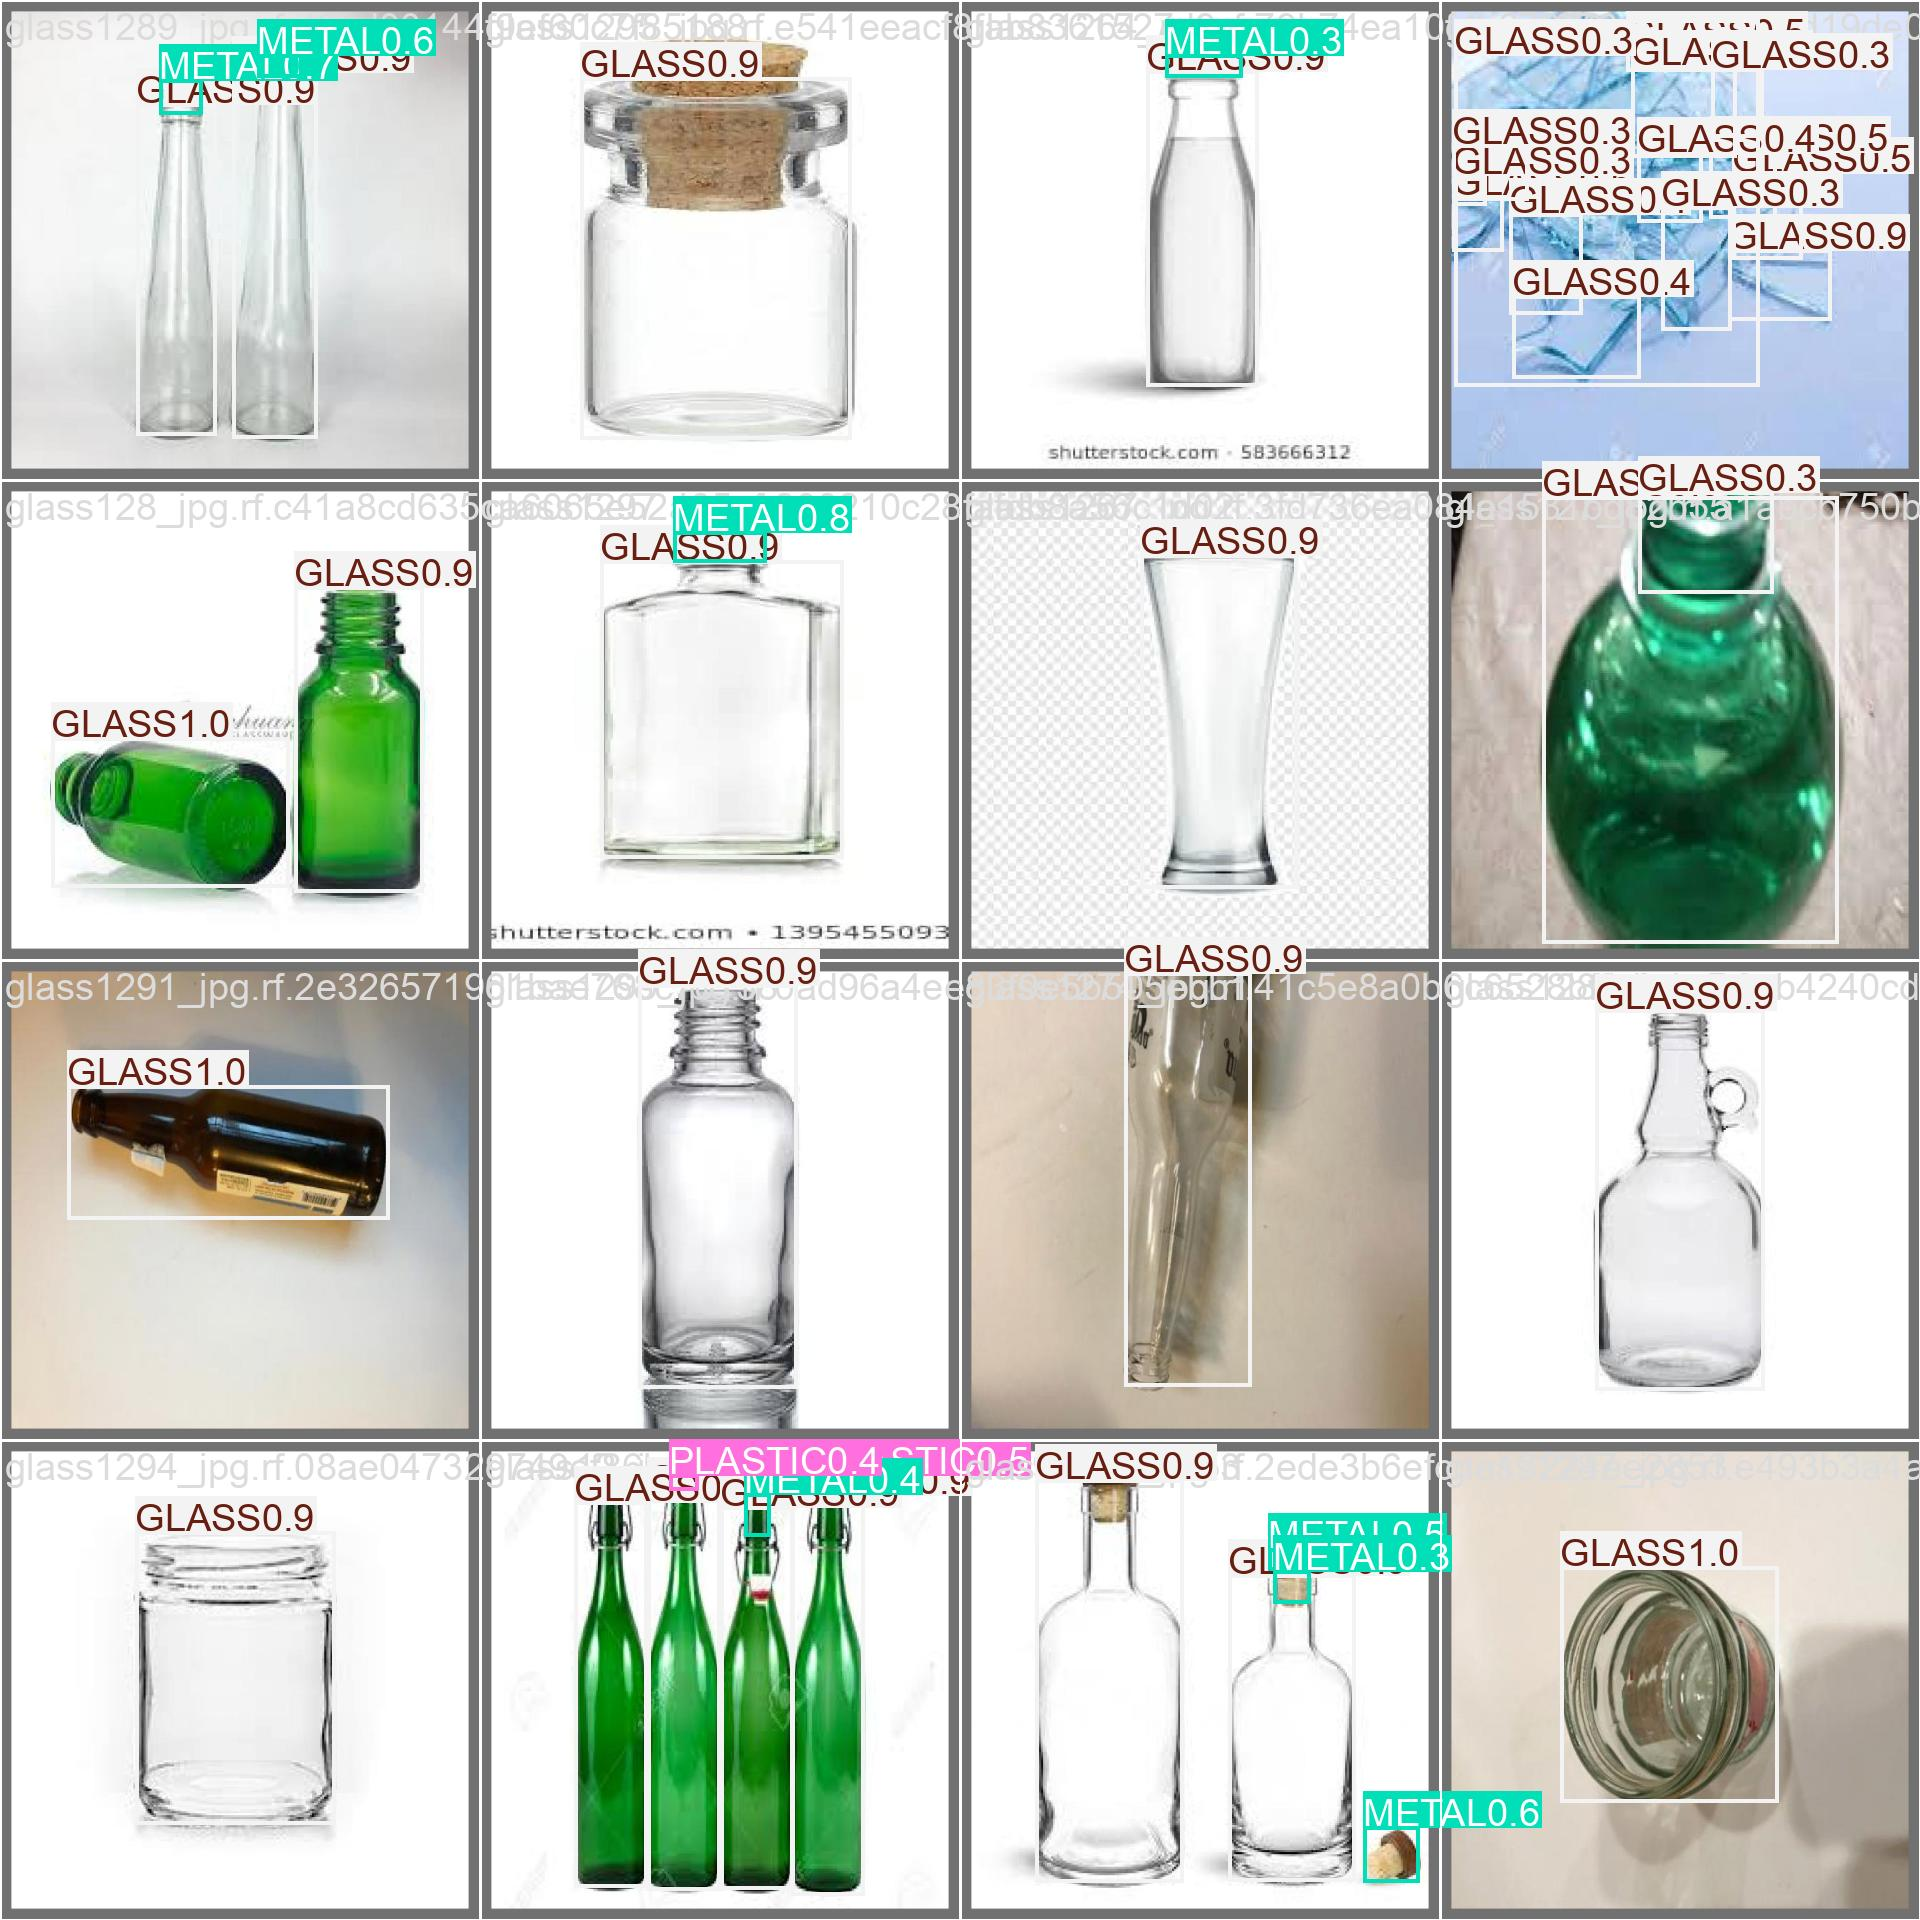

In [ ]:

from IPython.display import Image, display

display(Image("/content/runs/detect/trash_detection/val_batch0_pred.jpg"))
display(Image("/content/runs/detect/trash_detection/val_batch1_pred.jpg"))
display(Image("/content/runs/detect/trash_detection/val_batch2_pred.jpg"))

In [ ]:
import os

path = "/content/runs/detect/trash_detection"

for file in os.listdir(path):
    print(file)

train_batch10280.jpg
weights
val_batch1_pred.jpg
results.csv
train_batch1.jpg
results.png
confusion_matrix.png
train_batch0.jpg
train_batch10282.jpg
val_batch0_pred.jpg
BoxPR_curve.png
val_batch1_labels.jpg
confusion_matrix_normalized.png
BoxP_curve.png
BoxR_curve.png
val_batch2_labels.jpg
labels.jpg
val_batch2_pred.jpg
train_batch2.jpg
train_batch10281.jpg
args.yaml
val_batch0_labels.jpg
BoxF1_curve.png


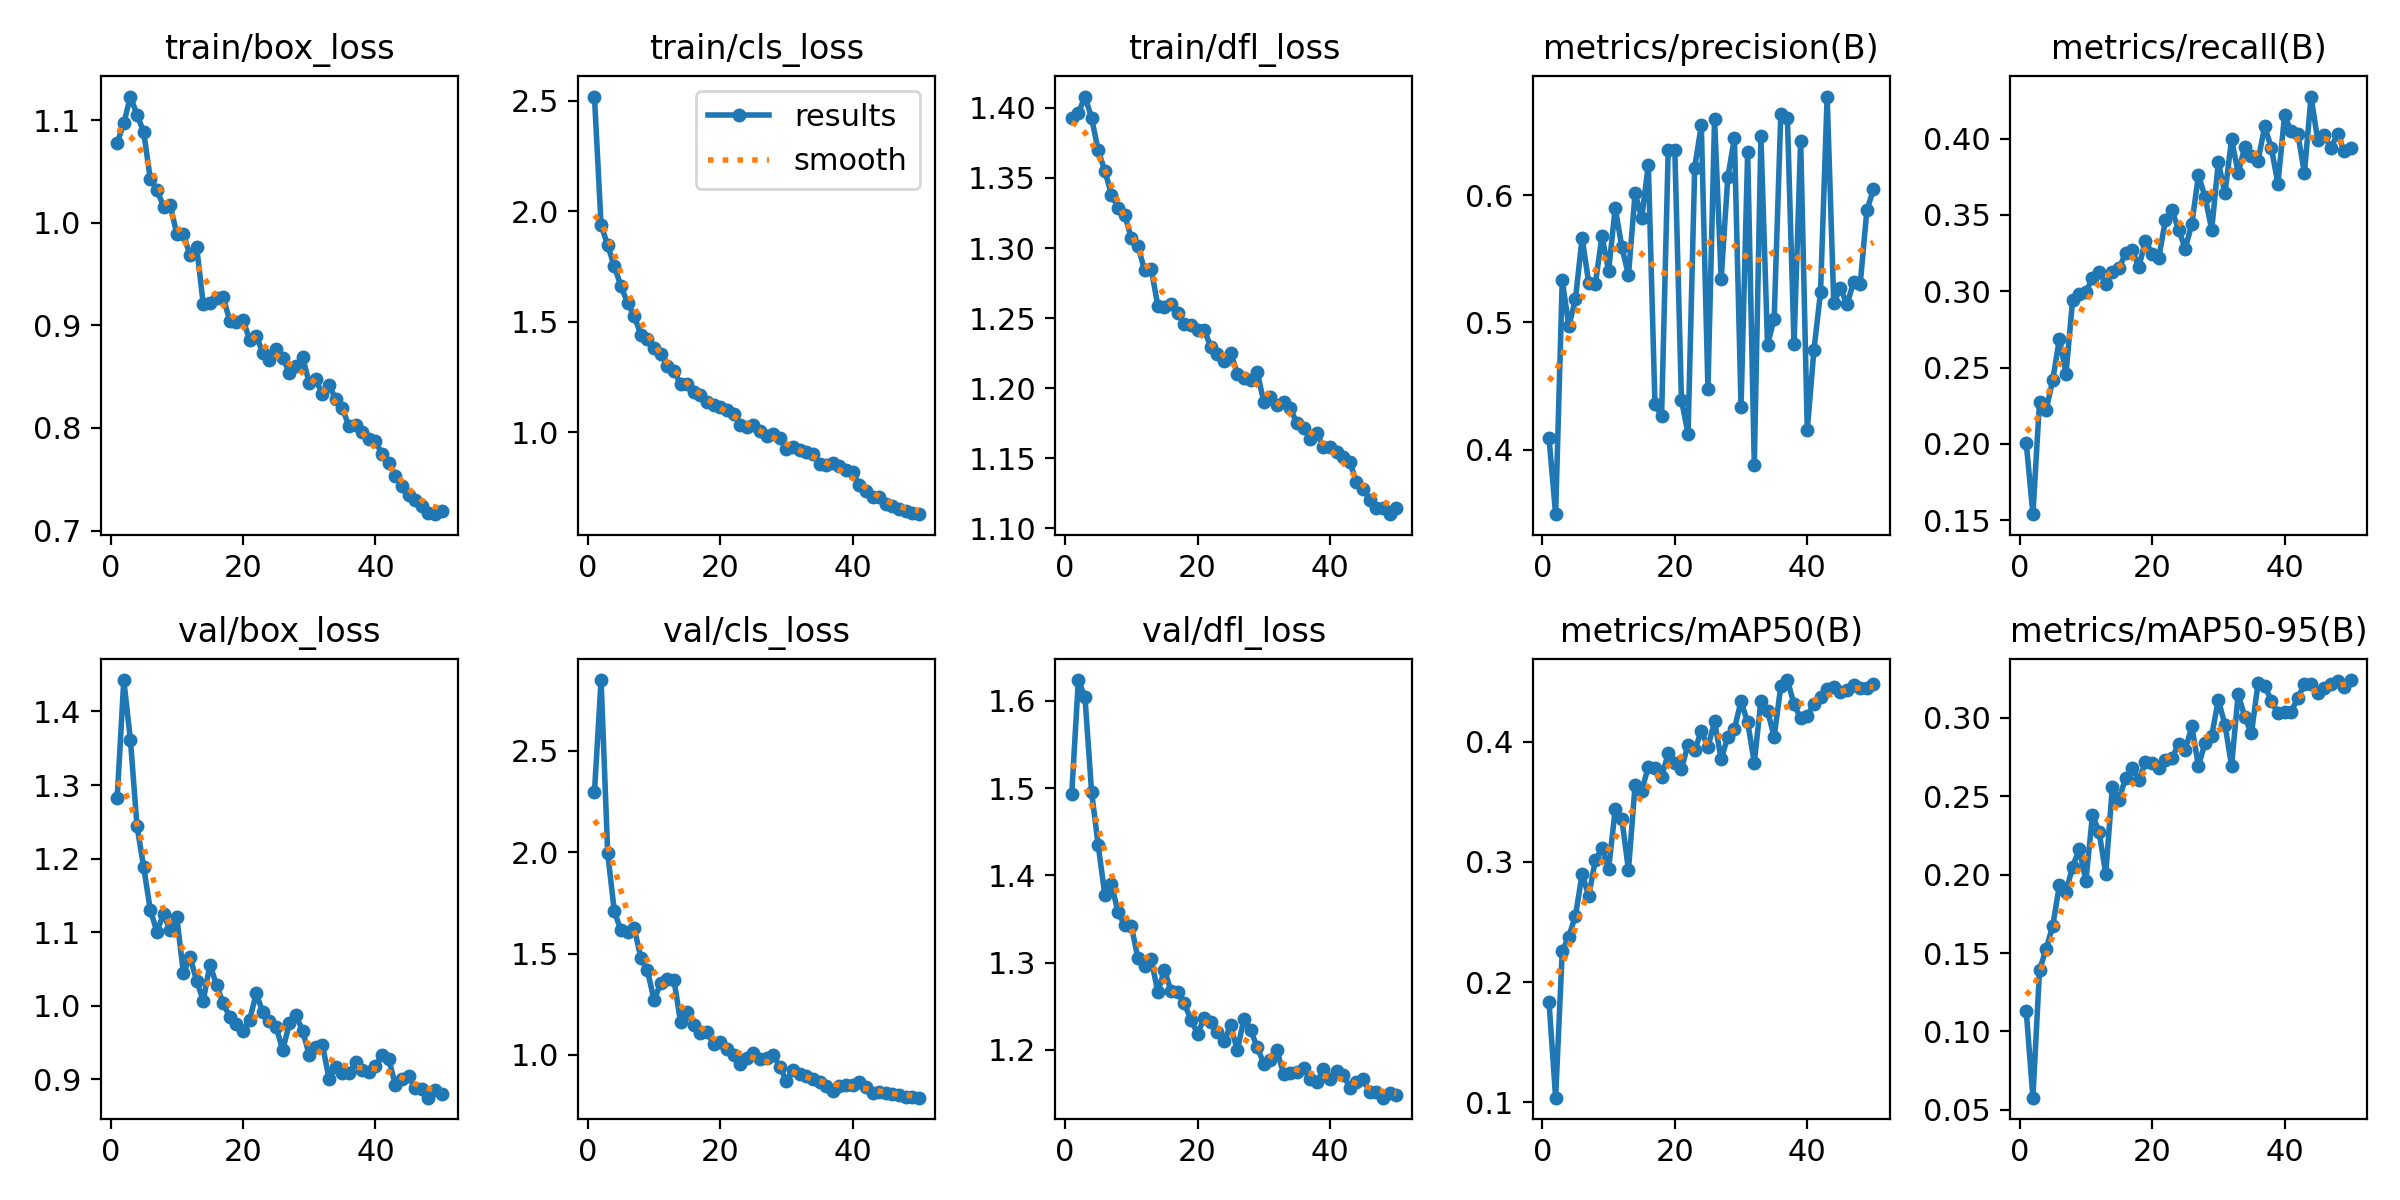

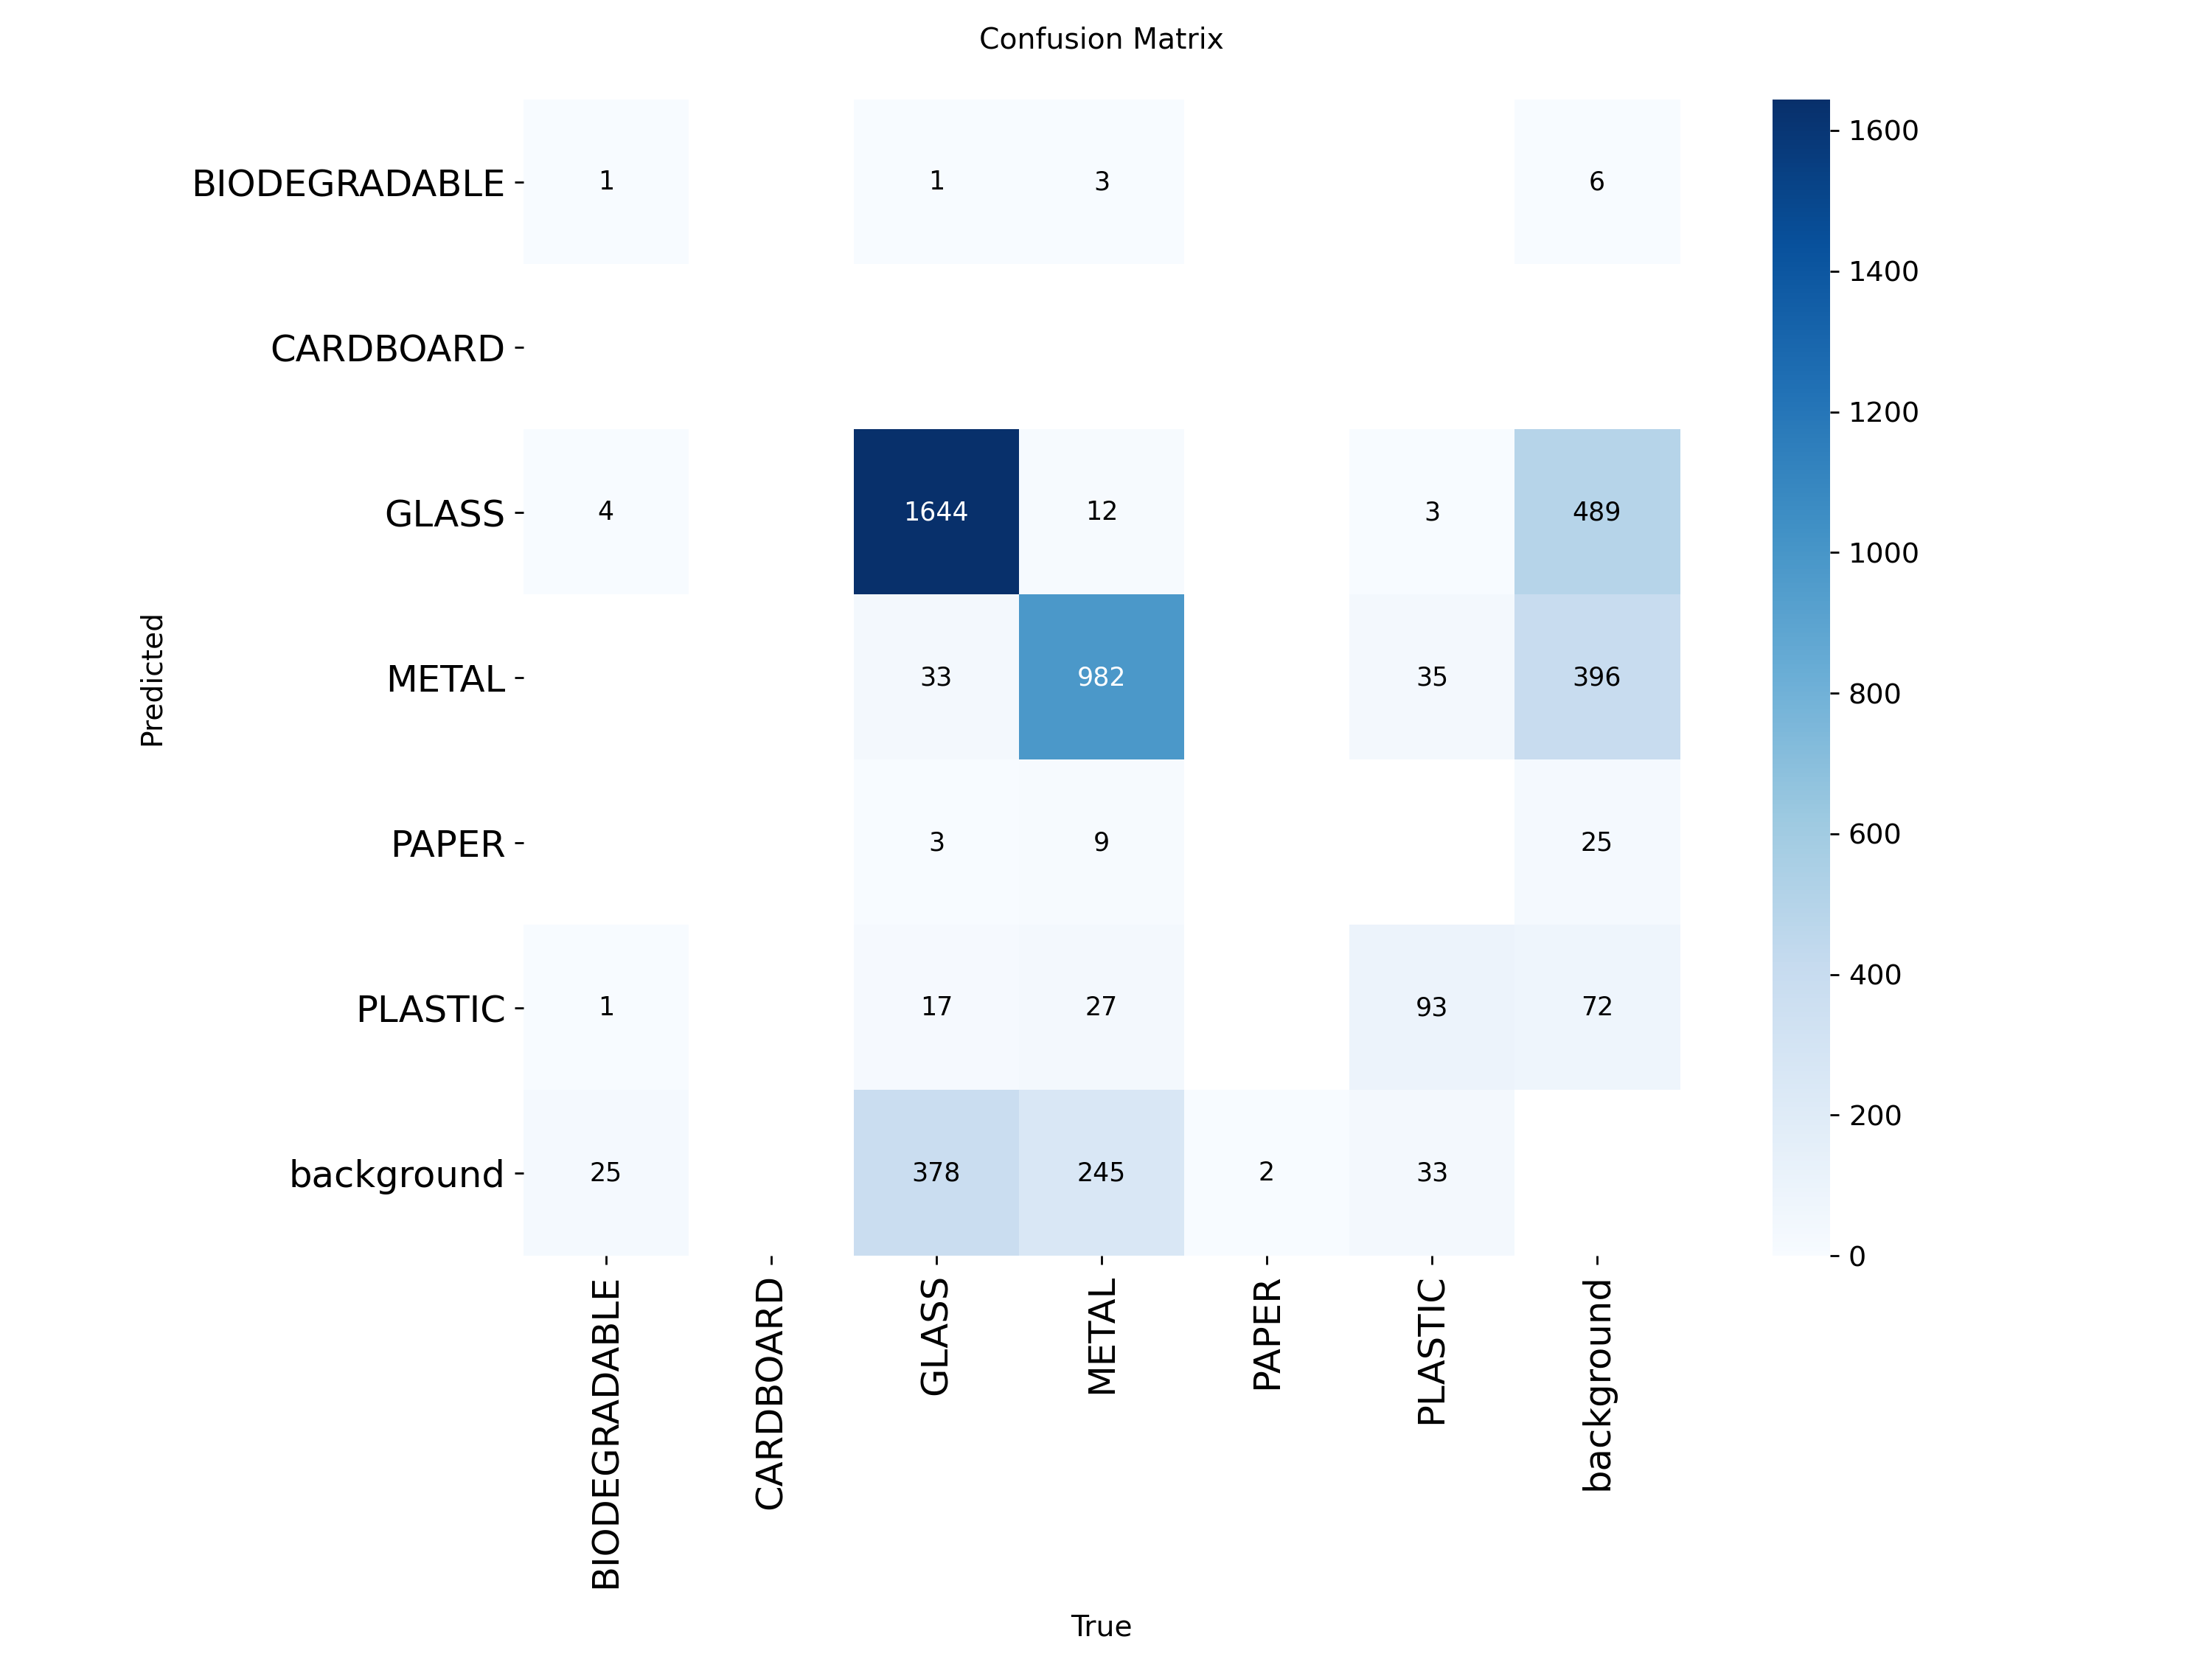

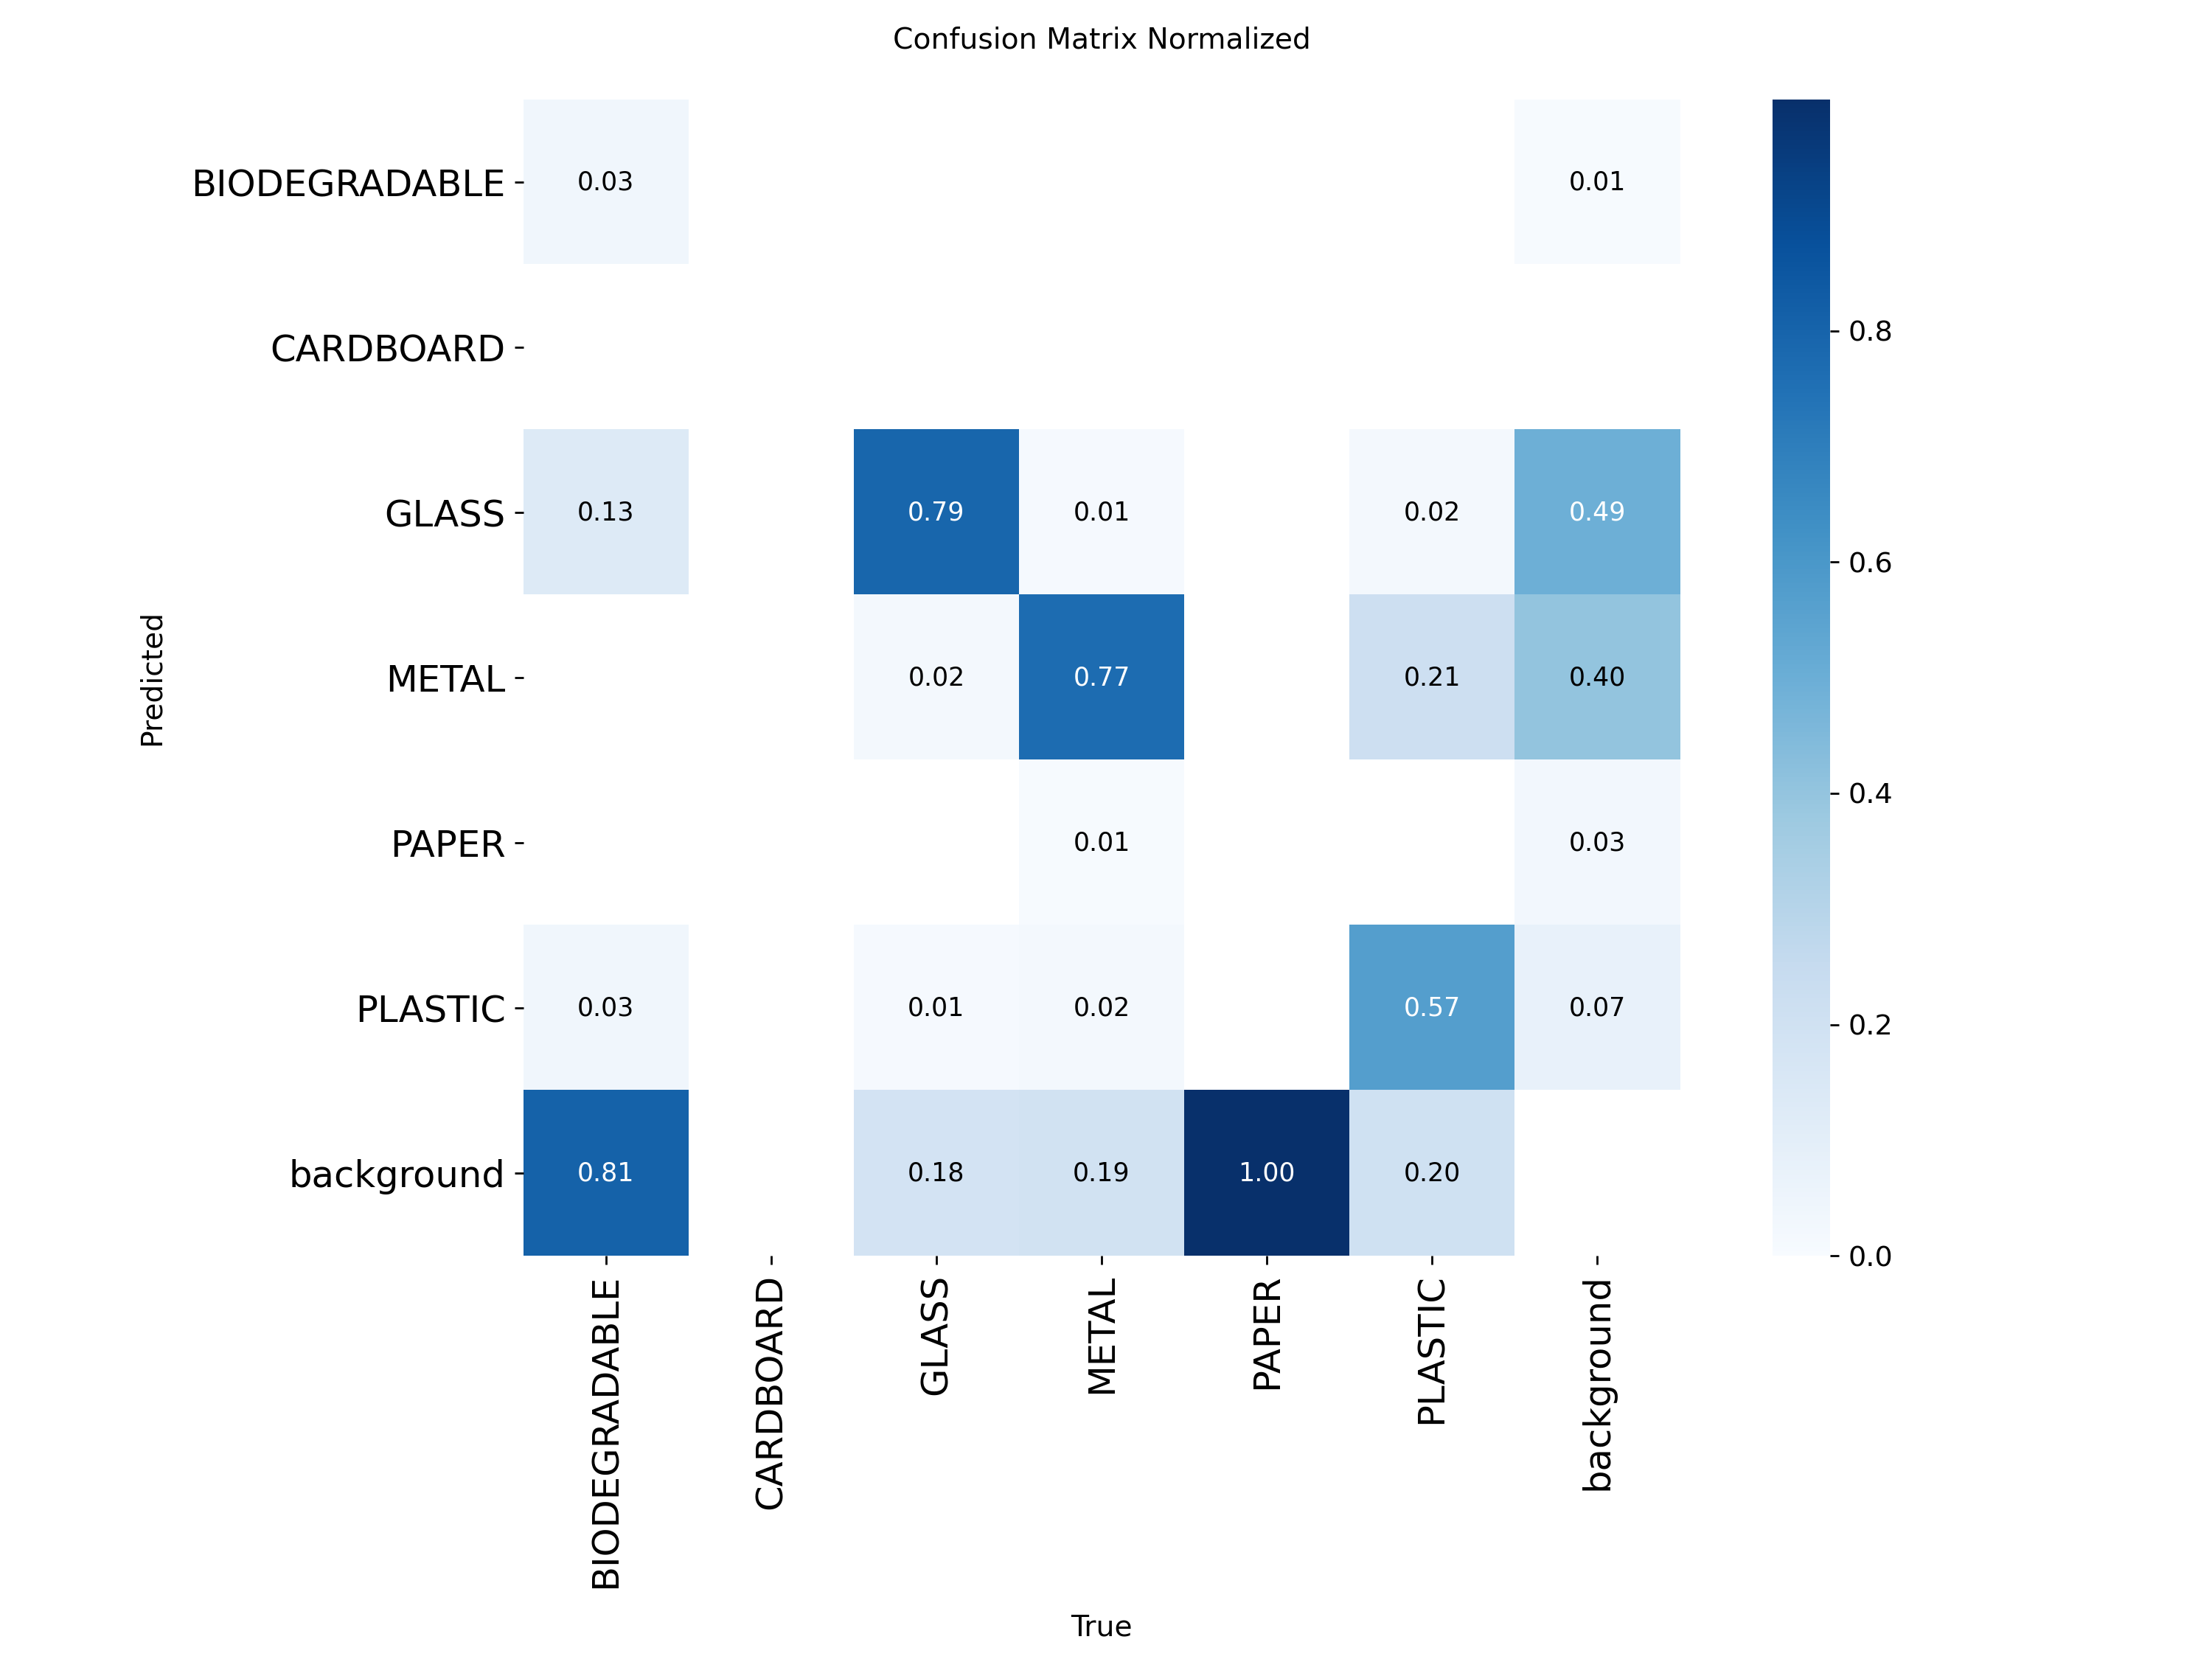

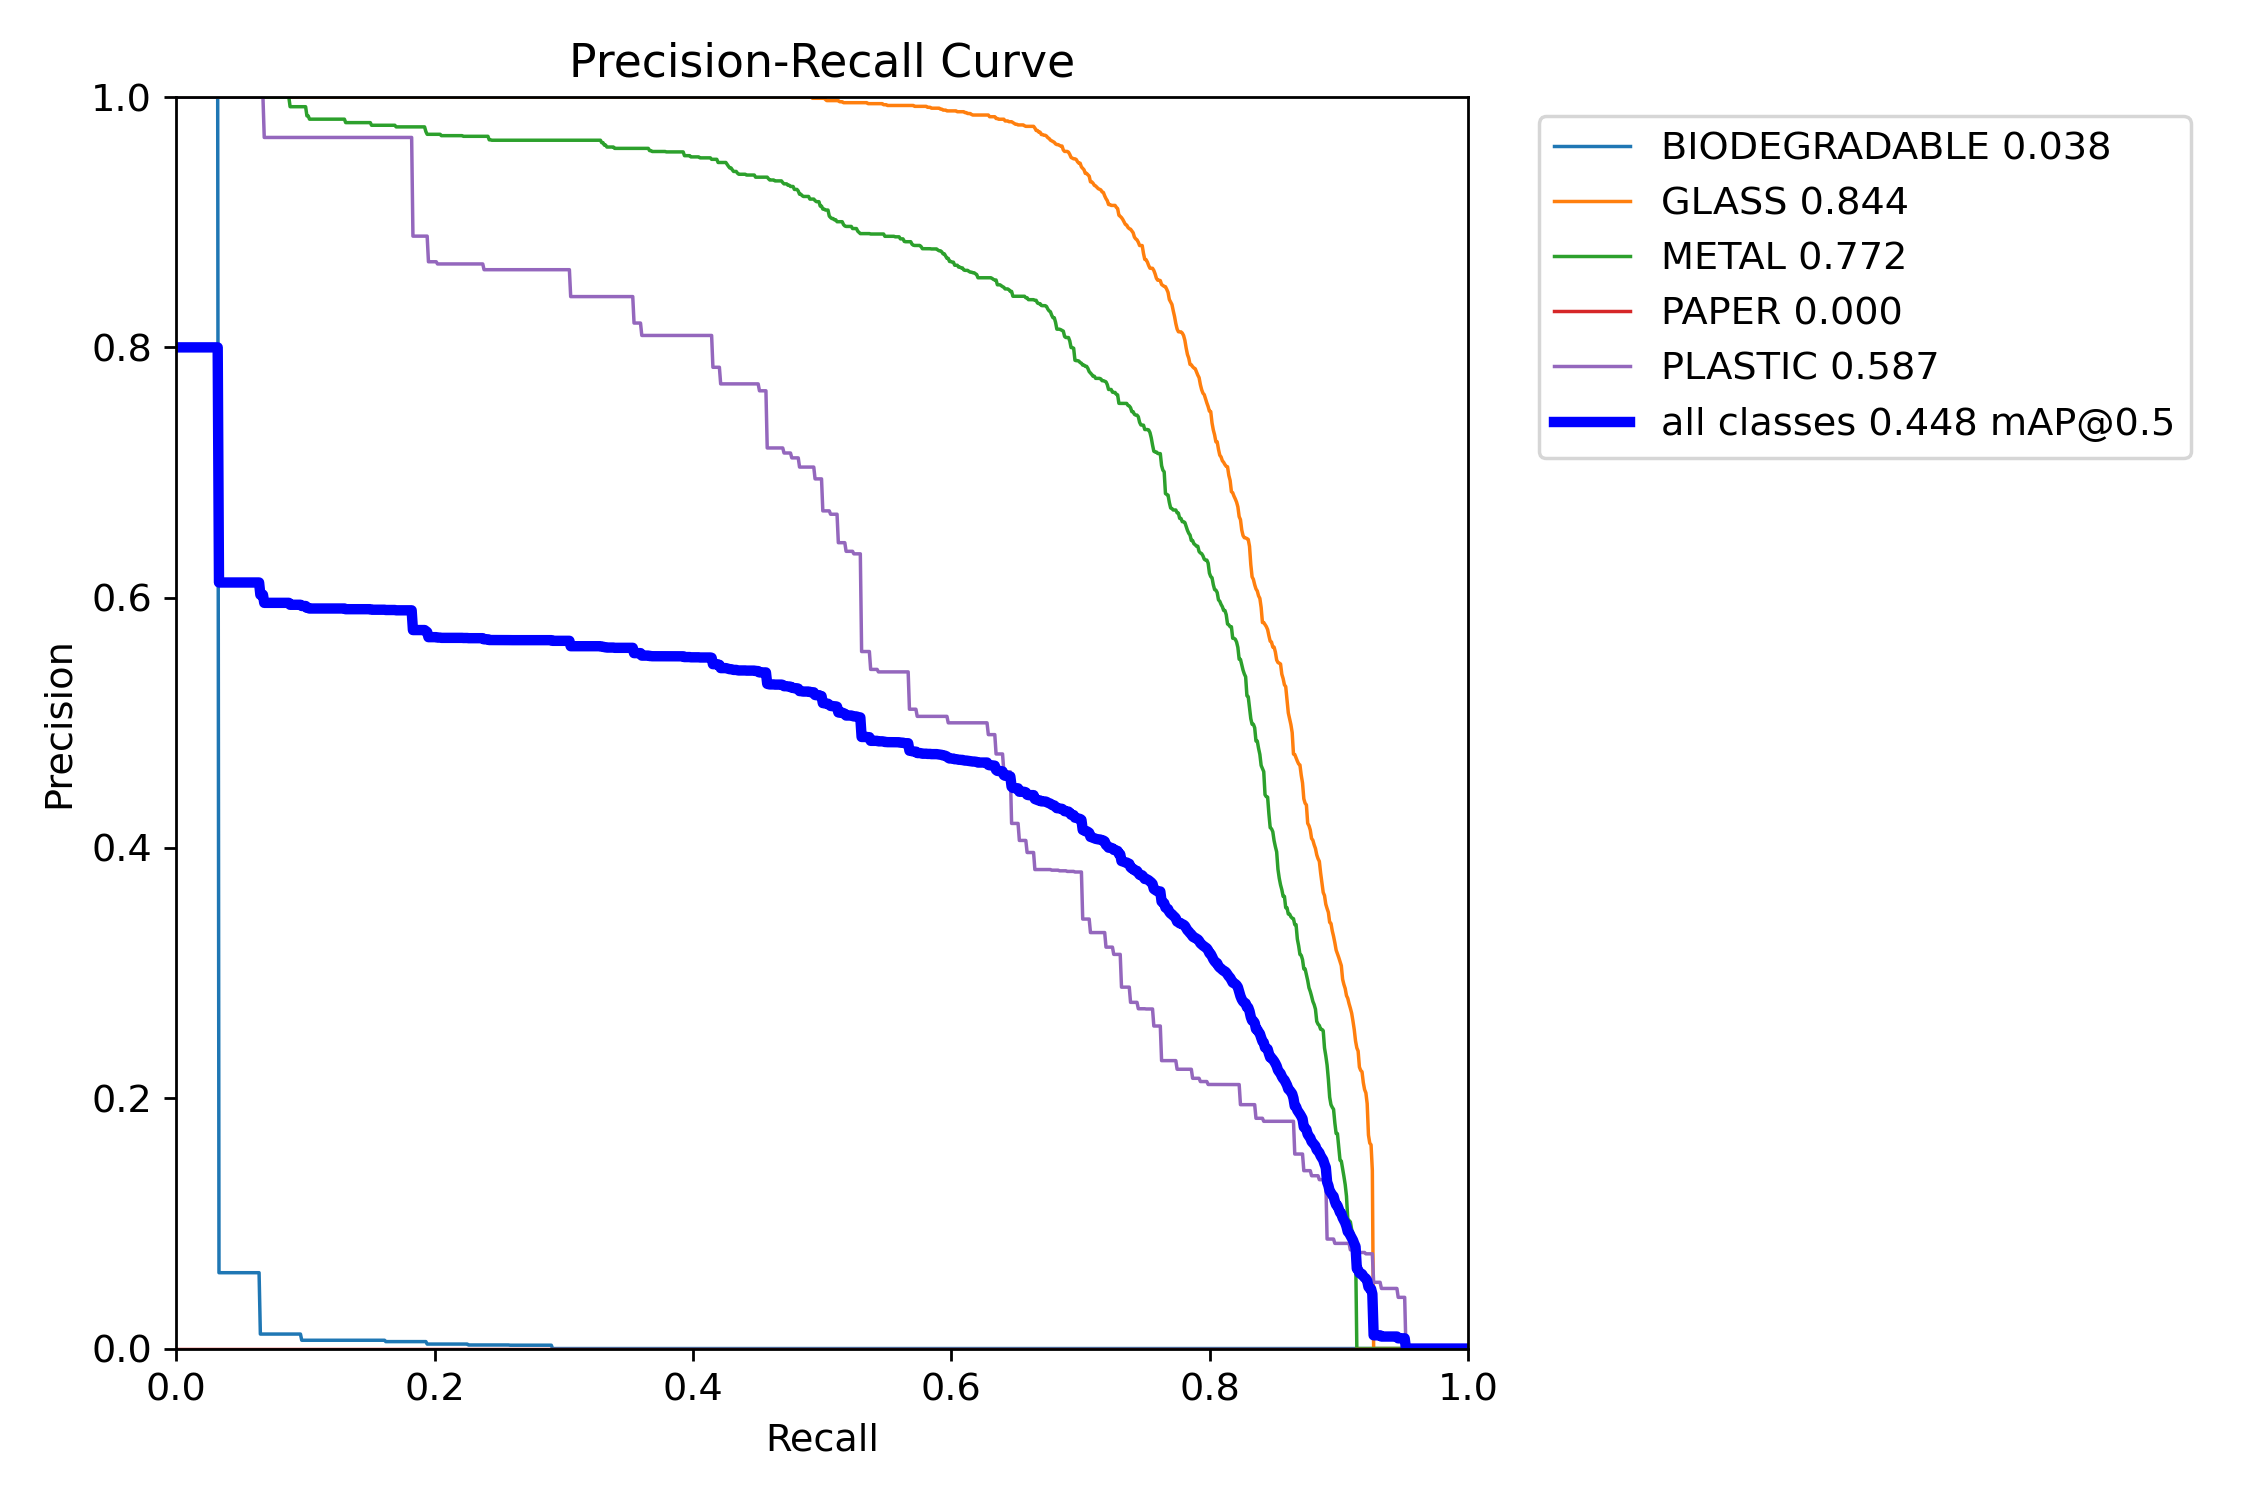

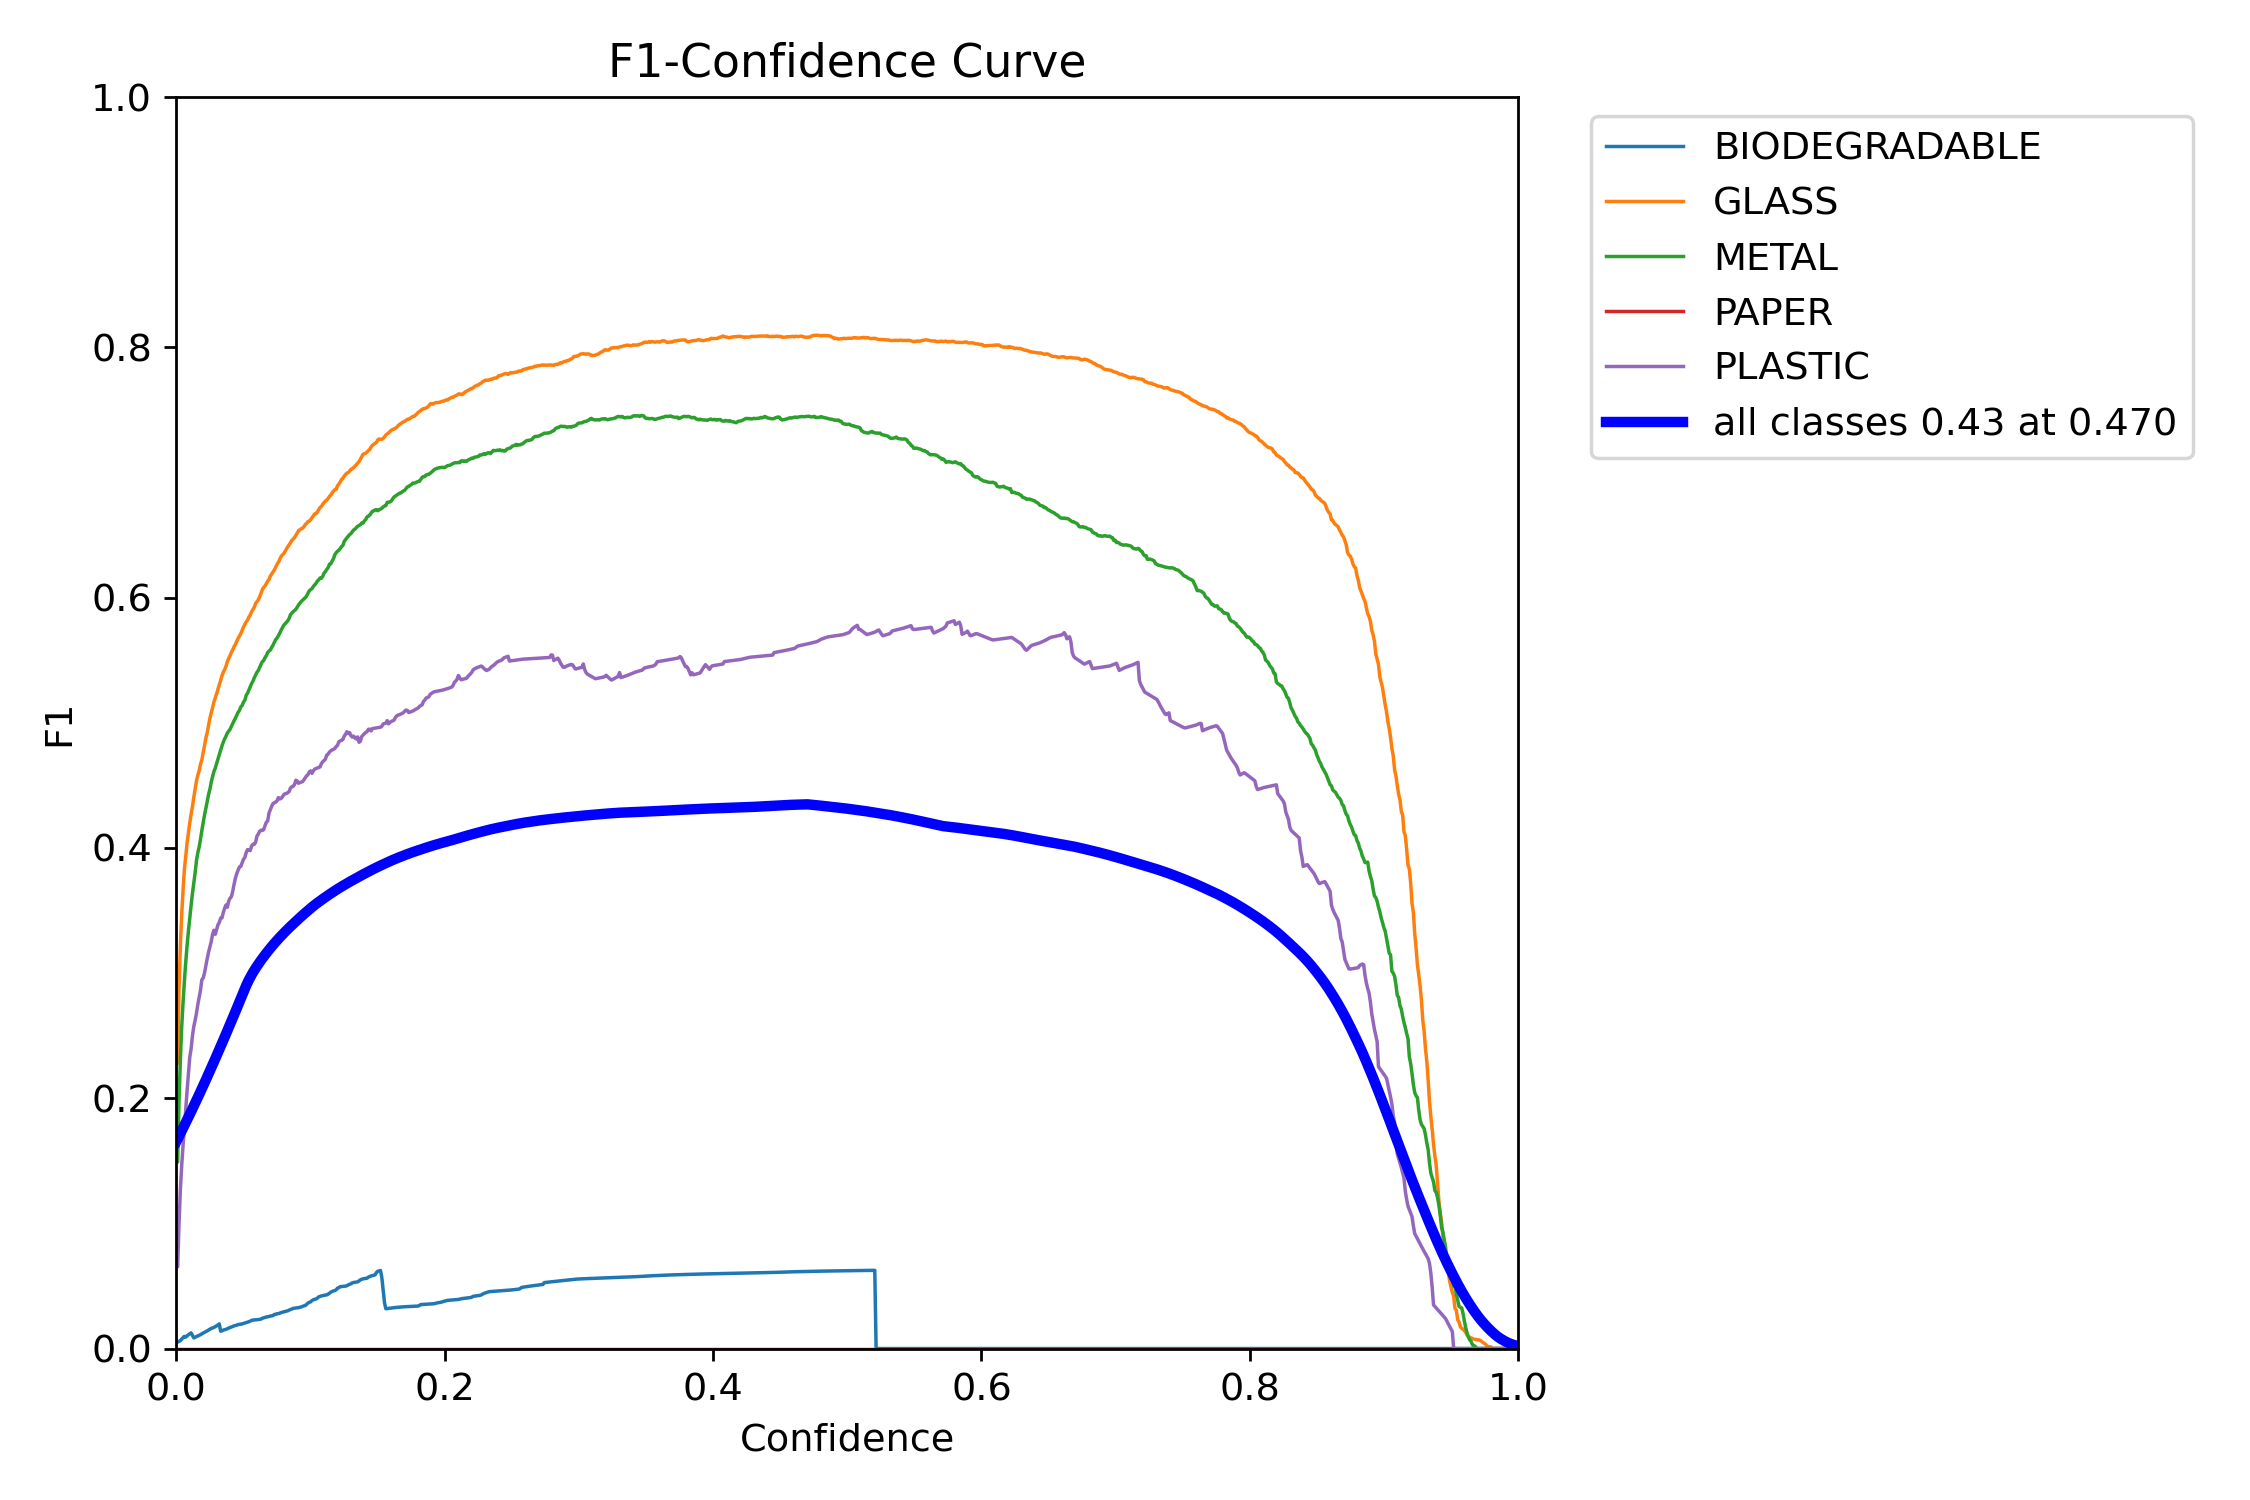

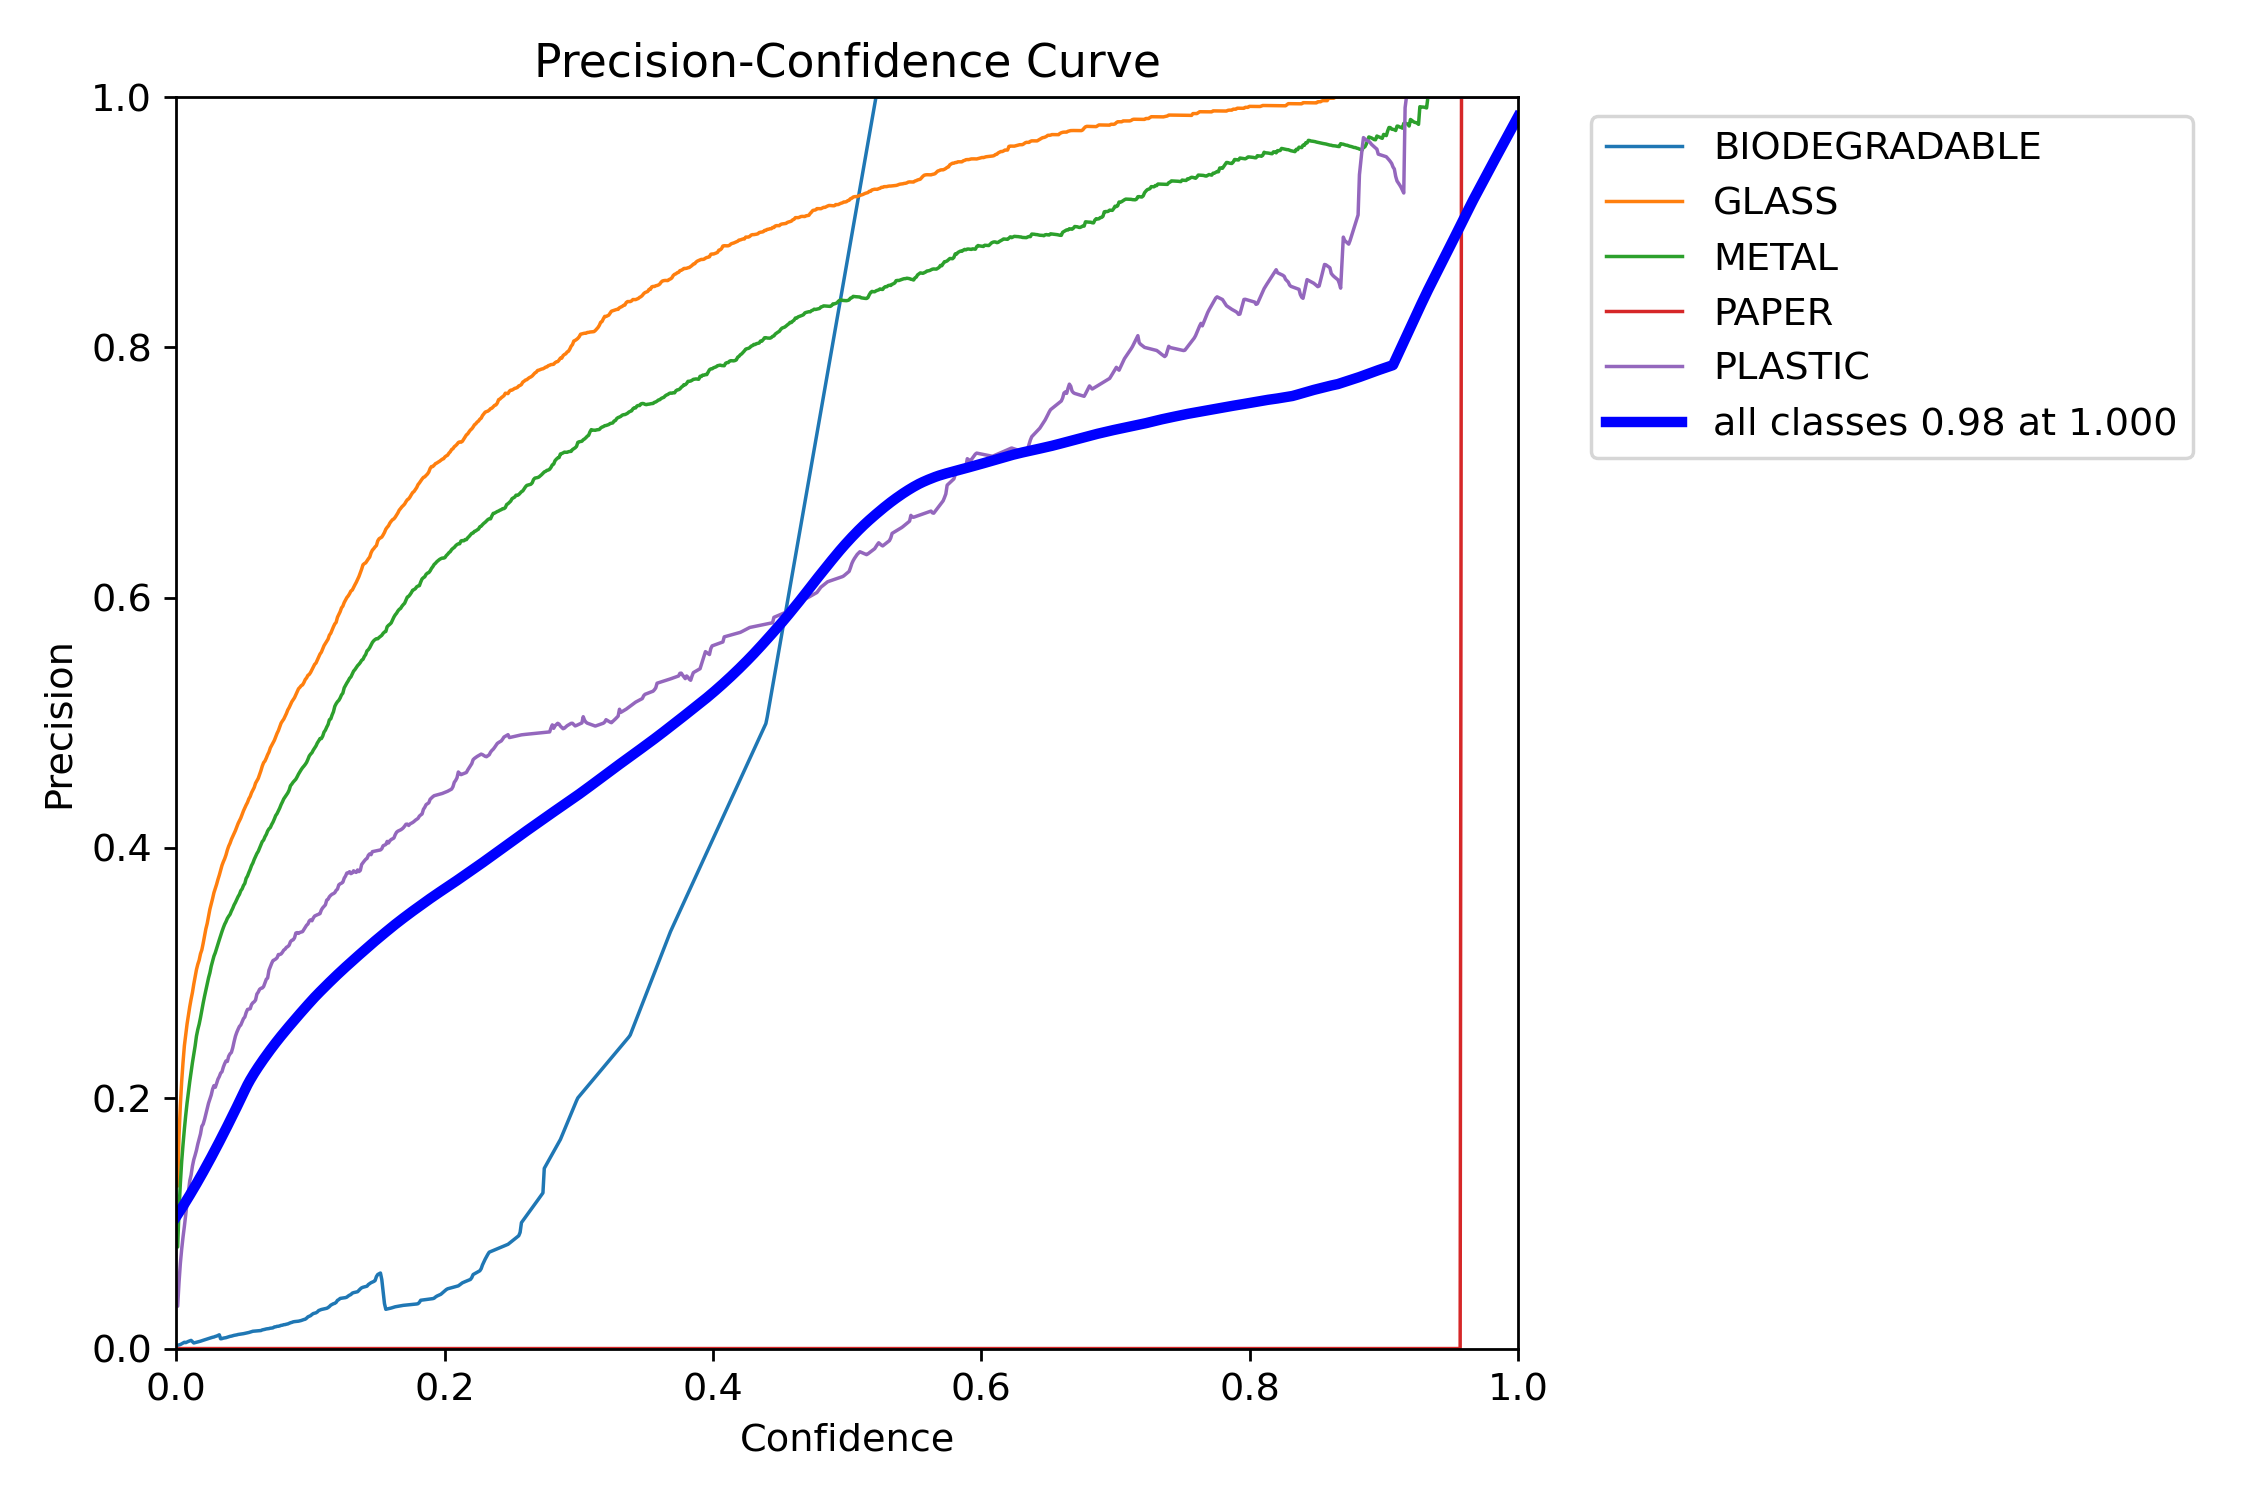

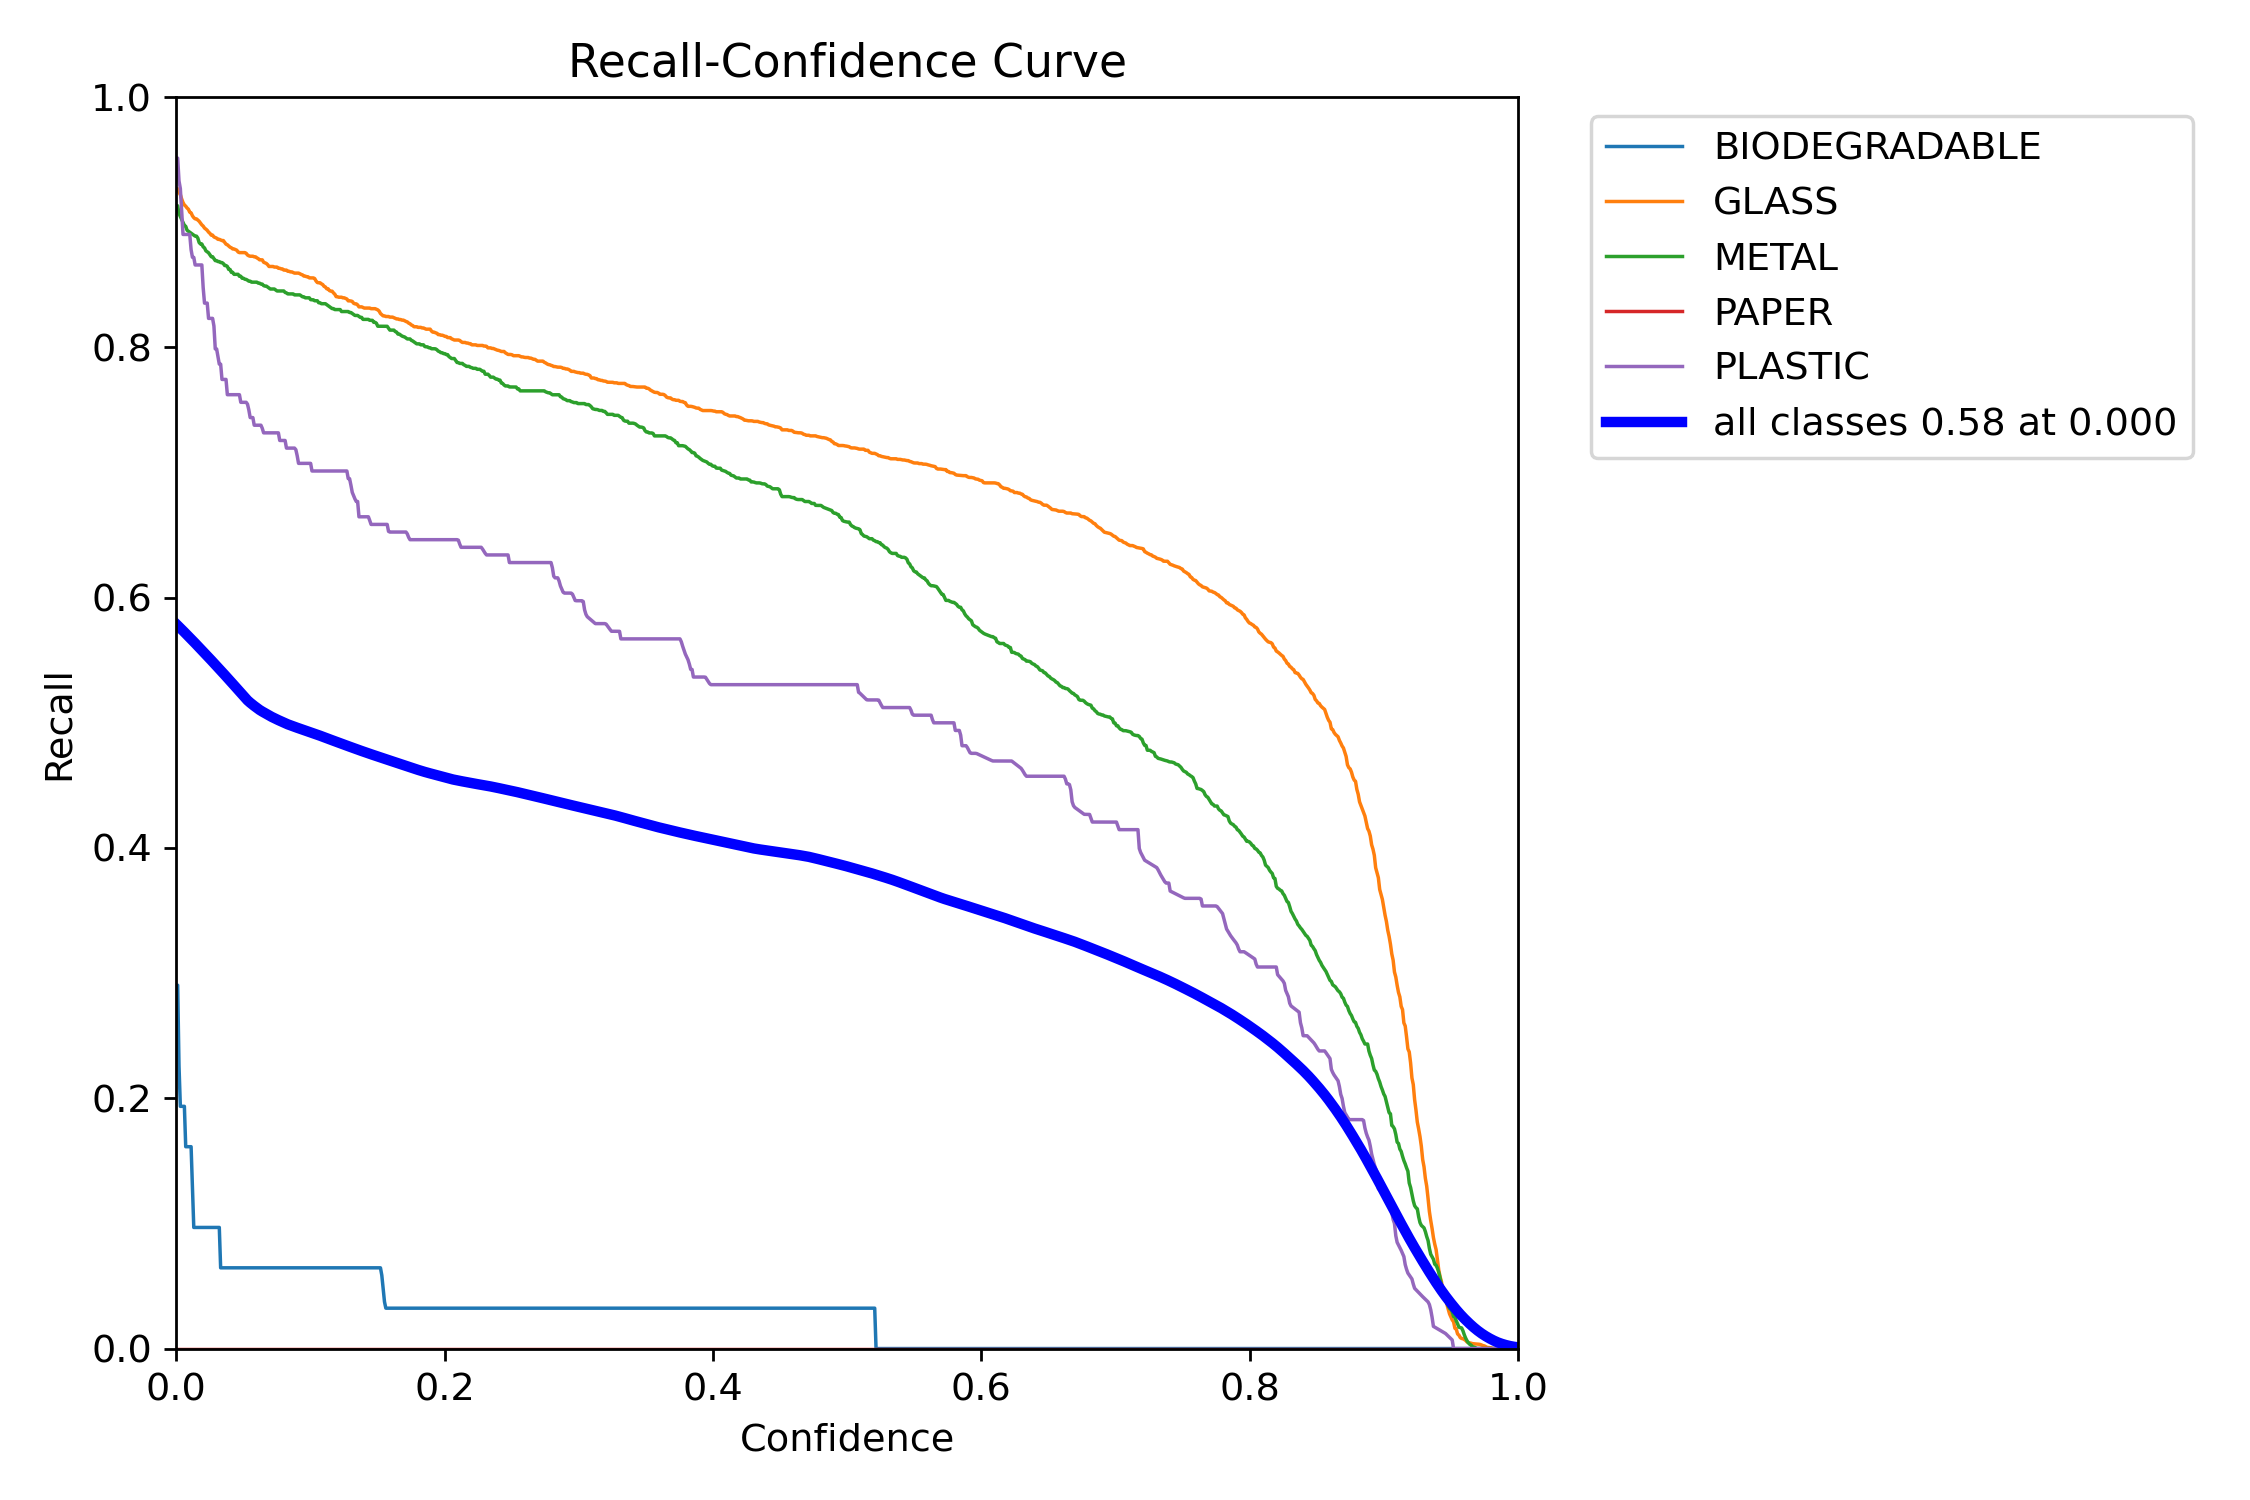

In [ ]:

from IPython.display import Image, display
display(Image("/content/runs/detect/trash_detection/results.png"))
display(Image("/content/runs/detect/trash_detection/confusion_matrix.png"))
display(Image("/content/runs/detect/trash_detection/confusion_matrix_normalized.png"))
display(Image("/content/runs/detect/trash_detection/BoxPR_curve.png"))
display(Image("/content/runs/detect/trash_detection/BoxF1_curve.png"))
display(Image("/content/runs/detect/trash_detection/BoxP_curve.png"))
display(Image("/content/runs/detect/trash_detection/BoxR_curve.png"))